# In Class May 19

In [2]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Importing the data

In [3]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

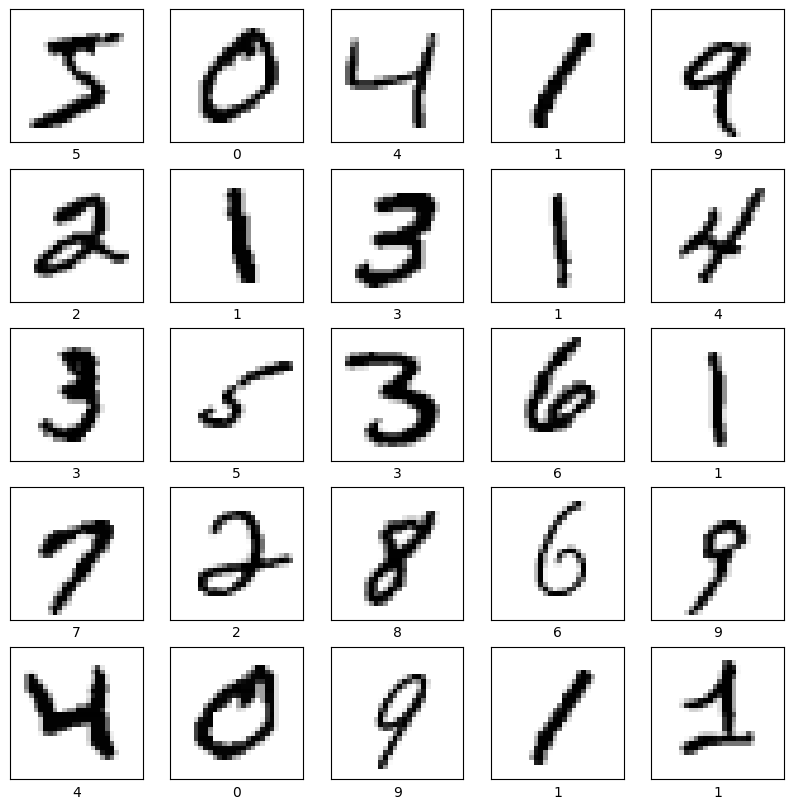

In [4]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [5]:

# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [6]:
# Define the MLP baseline model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9001 - loss: 0.3518 - val_accuracy: 0.9572 - val_loss: 0.1538
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9569 - loss: 0.1453 - val_accuracy: 0.9697 - val_loss: 0.1051
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9694 - loss: 0.1023 - val_accuracy: 0.9737 - val_loss: 0.0905
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9773 - loss: 0.0757 - val_accuracy: 0.9768 - val_loss: 0.0822
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9816 - loss: 0.0607 - val_accuracy: 0.9772 - val_loss: 0.0771
313/313 - 1s - 2ms/step - accuracy: 0.9744 - loss: 0.0865
MLP Test accuracy: 0.9744


### Preparing data for CNN

In [8]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000 iamges, 28 x 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [9]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # one CONV layer - apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [10]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.9479 - loss: 0.1734 - val_accuracy: 0.9813 - val_loss: 0.0694
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9816 - loss: 0.0599 - val_accuracy: 0.9858 - val_loss: 0.0557
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9871 - loss: 0.0407 - val_accuracy: 0.9868 - val_loss: 0.0525
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9914 - loss: 0.0280 - val_accuracy: 0.9868 - val_loss: 0.0532
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9934 - loss: 0.0202 - val_accuracy: 0.9877 - val_loss: 0.0557


### Evaluating the CNN model

In [11]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9848 - loss: 0.0487
CNN Test Accuracy: 0.9847999811172485


### MLP vs CNN model

In [12]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")


MLP Test accuracy: 0.9744
CNN Test accuracy: 0.9848


### Visualizing model training

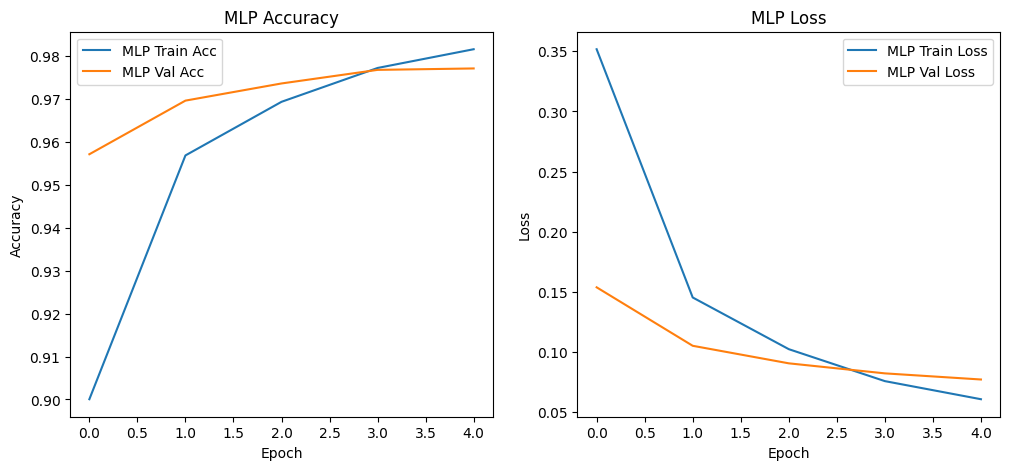

In [13]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


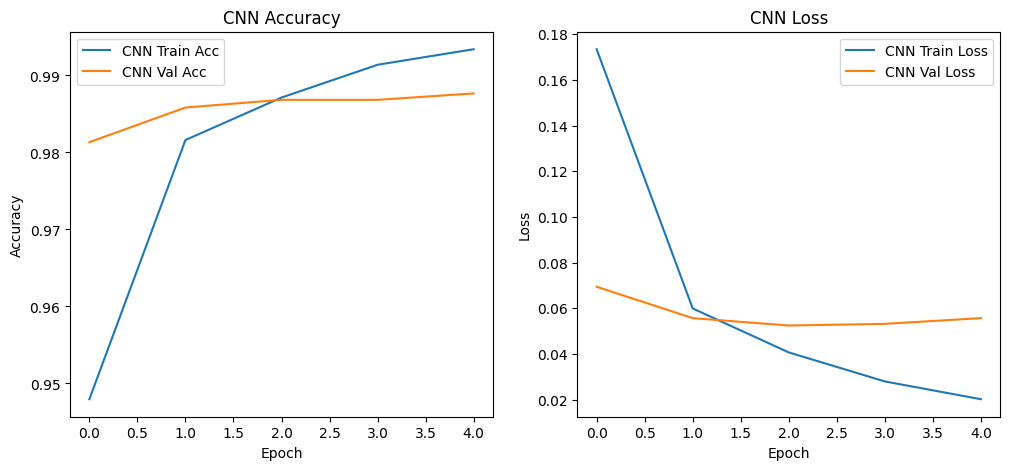

In [14]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


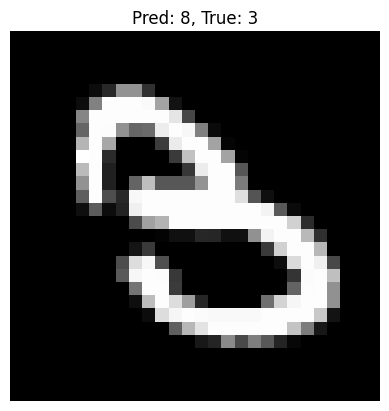

In [15]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

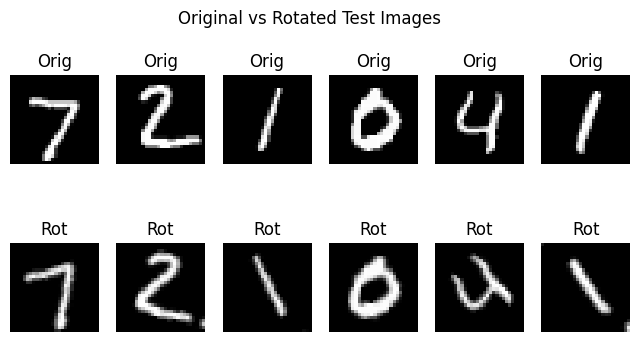

In [16]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [17]:
# testing on images above
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7024 - loss: 1.5401
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7651 - loss: 1.1761
MLP accuracy (original test): 0.974399983882904
MLP accuracy (rotated test): 0.7024000287055969
CNN accuracy (original test): 0.9847999811172485
CNN accuracy (rotated test): 0.7651000022888184


### New models trained with data augmentation (random rotations)

In [18]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [19]:
# Define the MLP baseline model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),       # second hidden layer with 64 neurons (learns patterns)
    layers.Dense(32, activation="relu"),        # third hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

# train the MLP model
history_mlp = mlp_model.fit(
    X_train_rot_train_flat,
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8020 - loss: 0.6399 - val_accuracy: 0.9182 - val_loss: 0.2757
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9153 - loss: 0.2807 - val_accuracy: 0.9293 - val_loss: 0.2283
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9362 - loss: 0.2098 - val_accuracy: 0.9478 - val_loss: 0.1696
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9495 - loss: 0.1665 - val_accuracy: 0.9490 - val_loss: 0.1644
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9569 - loss: 0.1396 - val_accuracy: 0.9482 - val_loss: 0.1612


In [20]:
# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_rot_train_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.9436 - loss: 0.1882
MLP Test accuracy: 0.9436


### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

In [21]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # one CONV layer - apply 32 filters to detect local patterns (edges, curves)
    layers.AveragePooling2D((3,3)),               # Changed to AveragePooling2D with pool size (3,3)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_rot_train_cnn,                        # Using rotated training images for CNN
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8551 - loss: 0.4755 - val_accuracy: 0.9453 - val_loss: 0.1860
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9440 - loss: 0.1879 - val_accuracy: 0.9610 - val_loss: 0.1270
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9569 - loss: 0.1386 - val_accuracy: 0.9675 - val_loss: 0.1086
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9652 - loss: 0.1131 - val_accuracy: 0.9727 - val_loss: 0.0981
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9700 - loss: 0.0965 - val_accuracy: 0.9707 - val_loss: 0.1002


In [22]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9684 - loss: 0.0986
CNN Test Accuracy: 0.9684000015258789


### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/tmp/ipykernel_5244/3750079556.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(range(n_classes))


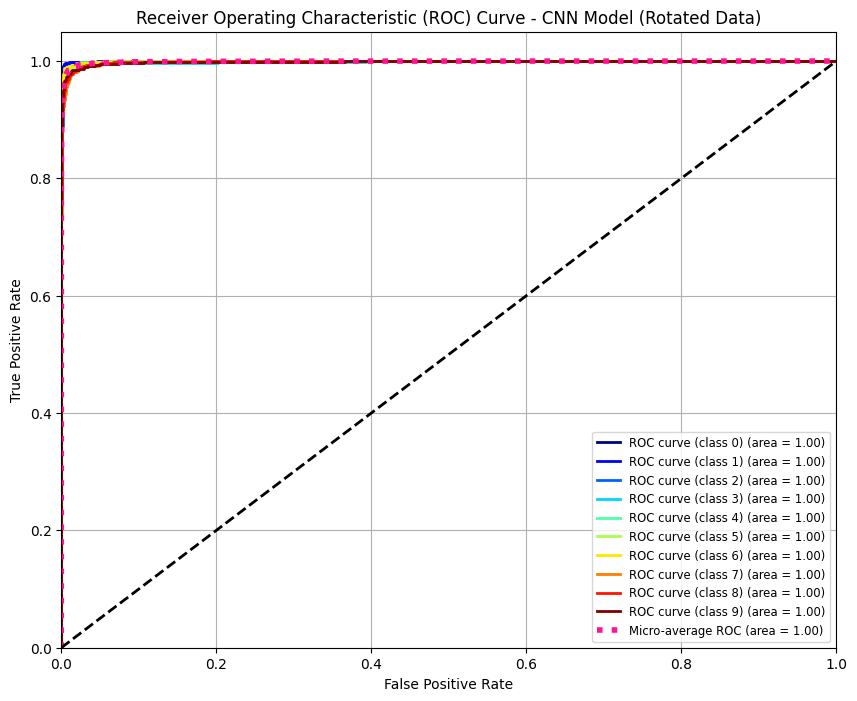

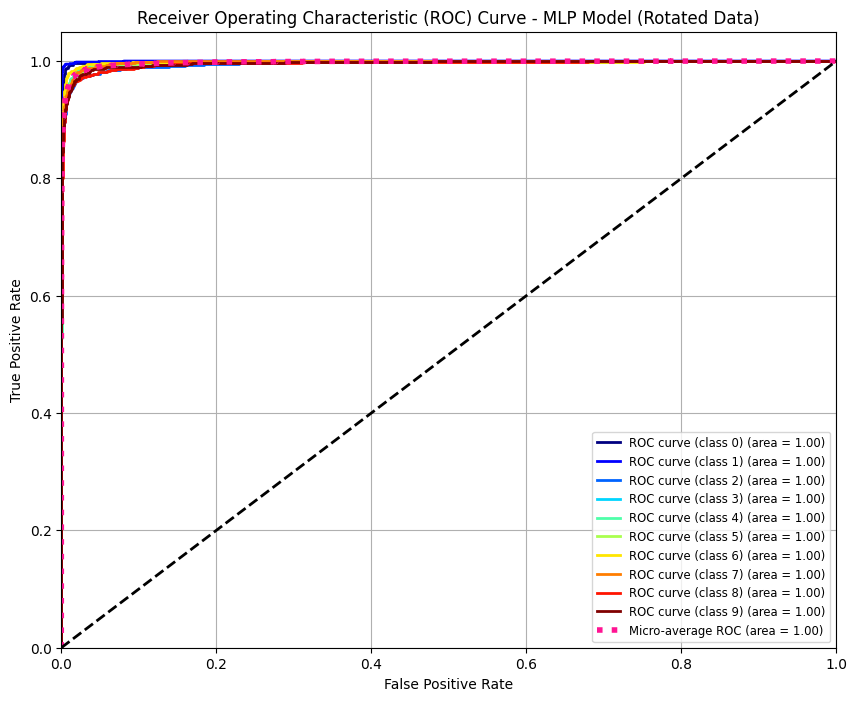

CNN Micro-average ROC AUC (Rotated Data): 0.9990
MLP Micro-average ROC AUC (Rotated Data): 0.9974


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Predict probabilities for both models
y_pred_cnn = cnn_model.predict(X_test_rot_train_cnn) # Modified to use rotated test data for CNN
y_pred_mlp = mlp_model.predict(X_test_rot_train_flat)

# Binarize the true labels for multi-class ROC
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)

n_classes = len(label_binarizer.classes_)

# --- Plot ROC AUC for CNN Model ---
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('jet', n_classes)(range(n_classes))

# Individual class ROC curves for CNN
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_cnn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC curve (class {i}) (area = {roc_auc:.2f})')

# Micro-average ROC curve for CNN
fpr_micro_cnn, tpr_micro_cnn, _ = roc_curve(y_test_binarized.ravel(), y_pred_cnn.ravel())
roc_auc_micro_cnn = auc(fpr_micro_cnn, tpr_micro_cnn)
plt.plot(fpr_micro_cnn, tpr_micro_cnn, label=f'Micro-average ROC (area = {roc_auc_micro_cnn:.2f})', color='deeppink', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - CNN Model (Rotated Data)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()

# --- Plot ROC AUC for MLP Model ---
plt.figure(figsize=(10, 8))

# Individual class ROC curves for MLP
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_mlp[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC curve (class {i}) (area = {roc_auc:.2f})')

# Micro-average ROC curve for MLP
fpr_micro_mlp, tpr_micro_mlp, _ = roc_curve(y_test_binarized.ravel(), y_pred_mlp.ravel())
roc_auc_micro_mlp = auc(fpr_micro_mlp, tpr_micro_mlp)
plt.plot(fpr_micro_mlp, tpr_micro_mlp, label=f'Micro-average ROC (area = {roc_auc_micro_mlp:.2f})', color='deeppink', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - MLP Model (Rotated Data)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()

print(f"CNN Micro-average ROC AUC (Rotated Data): {roc_auc_micro_cnn:.4f}")
print(f"MLP Micro-average ROC AUC (Rotated Data): {roc_auc_micro_mlp:.4f}")

## Model Performance Evaluation: MLP vs. CNN (with Rotated Data)

After training both the Multi-Layer Perceptron (MLP) and Convolutional Neural Network (CNN) models on the rotated training/testing data, I think they both performed very strong which makes sense considering that the dataset is small.

The CNN ended up performing slightly better than MLP in terms of accuracy (0.96 vs 0.94) and ROC AUC scores (0.999 vs .997). I think this is because of its ability to learn spatially invariant features through convolutional layers and spatial data which may make them better at handling tasks like rotation.